# `ReduCNN` Research Suite: Cats vs. Dogs 🐱🐶

This notebook executes structural pruning experiments on the **Cats vs. Dogs** dataset. This dataset provides a higher-resolution challenge (128x128) compared to CIFAR-10, testing the framework's ability to handle larger activation maps and binary classification tasks.

### ✨ ReduCNN v0.6.6 Features:
1. **Architecture Agnostic**: Support for ResNet, DenseNet, and complex DAG models via automatic dependency discovery.
2. **Surgical Pruning Clusters**: Identifies coupled layers that must be pruned together to maintain structural integrity.
3. **Advanced Visualizations**: Introducing the **'X-Ray'** visualizer for interactive dependency mapping.
4. **Hybrid Meta-Pruning**: SOTA data-driven pruning based on literature-grounded criteria.

## Notebook Guide
Recommended run order for presentation:
1. Bootloader and dataset setup
2. Baseline training and evaluation
3. Pruning run (produce `pruned_model` and `masks`)
4. Presentation Mode diagnostics section at the end


In [8]:
# --- STEP 0: GITHUB BOOTLOADER (v0.6.4 Colab Optimization) ---
import sys, os

# 1. Clone the repository from GitHub
repo_url = "https://github.com/albertraviss2023/activation-based-pruning.git"
repo_dir = "activation-based-pruning"

if not os.path.exists(repo_dir):
    print(f"🚀 Cloning {repo_url}...")
    !git clone {repo_url}
else:
    print(f"✅ Repository {repo_dir} already exists. Updating...")
    %cd {repo_dir}
    !git pull
    %cd ..

# 2. Environment Setup
os.chdir(repo_dir)
sys.path.insert(0, os.path.abspath("src"))

# 3. Install dependencies and editable package
!pip install -q --upgrade setuptools pip
!pip install -q kaggle
!pip install -e .

# 4. Load autoreload and Verify

# --- Python 3.12 Compatibility Shim ---
import sys
try:
    import imp
except ImportError:
    from types import ModuleType
    import importlib
    imp = ModuleType('imp')
    imp.reload = importlib.reload
    sys.modules['imp'] = imp
    print("🛠️ Applied Python 3.12 'imp' shim")

%load_ext autoreload
%autoreload 2
import reducnn
print(f"\n✅ System Ready! ReduCNN v0.6.6 loaded from: {reducnn.__file__}")

🚀 Cloning https://github.com/albertraviss2023/activation-based-pruning.git...
Cloning into 'activation-based-pruning'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 183 (delta 4), reused 39 (delta 4), pack-reused 72 (from 1)
Receiving objects: 100% (183/183), 113.17 MiB | 30.71 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Obtaining file:///content/activation-based-pruning/activation-based-pruning/activation-based-pruning/activation-based-pruning
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ReduCNN (pyproject.toml) ... done
  Created wheel for ReduCNN: filename=reducnn-0.44-0.editable-py3-none-any.whl size=3600 sha256=cf56a8f20e4ec0d0002ff1f1ab65d8d7d30aeedfc968af836d0fbe4884e829c0
  Stored

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

✅ System Ready! ReduCNN v0.6.6 loaded from: /content/activation-based-pruning/src/reducnn/__init__.py


In [ ]:
# --- GLOBAL EXPERIMENT CONFIGURATION ---
MODEL_TYPE = 'vgg16'      # options: 'resnet18', 'vgg16', 'resnet50', 'densenet121'
DATASET_NAME = 'Cats_Dogs'
INPUT_SHAPE = (3, 128, 128) # PyTorch format (C, H, W)
NUM_CLASSES = 2

print(f"🚀 Experiment Configured: {MODEL_TYPE} on {DATASET_NAME}")

In [ ]:
# --- RUN ID + ARTIFACT PERSISTENCE (v0.88) ---
from pathlib import Path
from datetime import datetime
import os, re

def _slug(x):
    s = re.sub(r"\s+", "-", str(x or "").strip().lower())
    s = re.sub(r"[^a-z0-9_.-]", "", s)
    s = s.strip("-._")
    return s or "unknown"

DATASET_KEY = _slug(globals().get('DATASET_KEY') or globals().get('DATASET_NAME') or globals().get('dataset_name') or 'dataset')
MODEL_KEY = _slug(globals().get('MODEL_TYPE') or globals().get('model_type') or 'model')
RUN_ID = globals().get('RUN_ID') or f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_{DATASET_KEY}_{MODEL_KEY}"

OUTPUT_ARTIFACT_DIR = Path('outputs') / 'experiments' / DATASET_KEY / MODEL_KEY / RUN_ID
SAVED_ARTIFACT_DIR = Path('saved_models') / 'artifacts' / DATASET_KEY / MODEL_KEY / RUN_ID
OUTPUT_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
SAVED_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

os.environ['REDUCNN_RUN_ID'] = str(RUN_ID)
os.environ['REDUCNN_DATASET_KEY'] = str(DATASET_KEY)
os.environ['REDUCNN_ARTIFACT_DIR'] = str(OUTPUT_ARTIFACT_DIR)
os.environ['REDUCNN_ARTIFACT_MIRROR_DIR'] = str(SAVED_ARTIFACT_DIR)

print(f"Run ID: {RUN_ID}")
print(f"Artifacts: {OUTPUT_ARTIFACT_DIR}")
print(f"Artifacts mirror: {SAVED_ARTIFACT_DIR}")


In [ ]:
# --- Custom method registration (v0.88 unified: torch + keras) ---
from reducnn.pruner import register_method
import numpy as np

def _tools(kwargs):
    t = kwargs.get('tools', None)
    if t is None:
        raise ValueError('Backend tools not provided. Ensure adapter passes custom-method tools.')
    return t

def _max_batches(kwargs):
    val = kwargs.get('calib_batches', kwargs.get('prune_batches', kwargs.get('calibration_batches', None)))
    return int(val) if val else None

@register_method('custom_l2', framework='torch')
@register_method('custom_l2', framework='keras')
def custom_l2_score(layer, **kwargs):
    tools = _tools(kwargs)
    mode = str(kwargs.get('l2_mode', 'sum')).lower().strip()
    return np.asarray(tools.weight_l2(layer, mode=mode), dtype=np.float64).reshape(-1)

@register_method('chip', framework='torch')
@register_method('chip', framework='keras')
def chip_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return None
    max_spatial = kwargs.get('chip_max_spatial', None)
    return np.asarray(tools.chip_scores(A, max_spatial=max_spatial), dtype=np.float64).reshape(-1)

@register_method('custom_nisp', framework='torch')
@register_method('custom_nisp', framework='keras')
def custom_nisp_score(layer, **kwargs):
    tools = _tools(kwargs)
    lname = kwargs.get('layer_name', None)
    if lname is None:
        return np.asarray(tools.weight_l2(layer, mode='sum'), dtype=np.float64).reshape(-1)
    score_map = tools.nisp_score_map(max_batches=_max_batches(kwargs))
    s = score_map.get(lname, None)
    if s is None:
        return np.asarray(tools.weight_l2(layer, mode='sum'), dtype=np.float64).reshape(-1)
    return np.asarray(s, dtype=np.float64).reshape(-1)

@register_method('custom_spectral_energy', framework='torch')
@register_method('custom_spectral_energy', framework='keras')
def custom_spectral_energy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode='sum'), dtype=np.float64).reshape(-1)
    max_fft_samples = int(kwargs.get('max_fft_samples', 32))
    return np.asarray(tools.spectral_energy_scores(A, max_samples=max_fft_samples), dtype=np.float64).reshape(-1)

print('Custom methods registered: custom_l2, chip, custom_nisp, custom_spectral_energy (torch+keras).')


In [ ]:
# --- CSV artifact persistence helper (v0.88) ---
import os
import shutil
from pathlib import Path
import pandas as pd

def _artifact_root():
    out = globals().get('OUTPUT_ARTIFACT_DIR', None)
    if out is None:
        out = os.environ.get('REDUCNN_ARTIFACT_DIR', None)
    if out is None:
        out = Path('outputs') / 'experiments' / 'unknown'
    return Path(out)

def _artifact_mirror_root():
    mir = globals().get('SAVED_ARTIFACT_DIR', None)
    if mir is None:
        mir = os.environ.get('REDUCNN_ARTIFACT_MIRROR_DIR', None)
    return Path(mir) if mir else None

def _to_df(obj):
    if isinstance(obj, pd.DataFrame):
        return obj
    if isinstance(obj, list) and len(obj) > 0 and isinstance(obj[0], dict):
        return pd.DataFrame(obj)
    if isinstance(obj, dict):
        try:
            return pd.DataFrame(obj)
        except Exception:
            return pd.DataFrame([obj])
    return None

def persist_notebook_tables(namespace, prefix='results'):
    run_id = str(globals().get('RUN_ID', os.environ.get('REDUCNN_RUN_ID', 'run')))
    out_root = _artifact_root() / 'tables'
    out_root.mkdir(parents=True, exist_ok=True)
    mir_root = _artifact_mirror_root()
    if mir_root is not None:
        (mir_root / 'tables').mkdir(parents=True, exist_ok=True)

    saved = []
    key_tokens = ('result', 'summary', 'report', 'metric', 'table', 'record', 'comparison')
    for name, obj in namespace.items():
        lname = str(name).lower()
        if name.startswith('_'):
            continue
        if not any(t in lname for t in key_tokens):
            continue
        df = _to_df(obj)
        if df is None or df.empty:
            continue
        f = out_root / f'{run_id}_{prefix}_{name}.csv'
        df.to_csv(f, index=False)
        if mir_root is not None:
            mf = (mir_root / 'tables') / f.name
            shutil.copy2(f, mf)
        saved.append(str(f))
    return saved


In [9]:
# =========================================================
# 🐶🐱 KAGGLE DOGS VS CATS — END-TO-END WORKFLOW
# =========================================================

import os
import zipfile
import subprocess
from pathlib import Path
import glob
import random
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image, UnidentifiedImageError

# -------------------------------
# 📁 Paths
# -------------------------------
data_base_dir = Path("./data/cats_dogs")
data_base_dir.mkdir(parents=True, exist_ok=True)

competition_zip = data_base_dir / "dogs-vs-cats.zip"
train_zip = data_base_dir / "train.zip"
train_dir = data_base_dir / "train"

# -------------------------------
# 🔑 Ensure Kaggle API
# -------------------------------
kaggle_dir = Path.home() / ".kaggle"
kaggle_json = kaggle_dir / "kaggle.json"

if not kaggle_json.exists():
    # Check if user uploaded it to the current directory or parent (Colab style)
    if Path("kaggle.json").exists():
        k_source = Path("kaggle.json")
    elif Path("../kaggle.json").exists():
        k_source = Path("../kaggle.json")
    else:
        k_source = None

    if k_source:
        try:
            import json
            with open(k_source, "r") as f:
                creds = json.load(f)
                os.environ['KAGGLE_USERNAME'] = creds.get('username', '')
                os.environ['KAGGLE_KEY'] = creds.get('key', creds.get('api_key', ''))
            print(f"✅ Credentials loaded from {k_source} and set as environment variables.")
            
            # Also maintain the file-based backup
            kaggle_dir.mkdir(parents=True, exist_ok=True)
            import shutil
            shutil.copy(str(k_source), str(kaggle_json))
            kaggle_json.chmod(0o600)
        except Exception as e:
            print(f"⚠️ Error loading credentials from {k_source}: {e}")

# -------------------------------
# ⚙️ Helper
# -------------------------------
def _run(cmd):
    print("$", " ".join(cmd))
    import subprocess
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"❌ Command failed with exit code {result.returncode}")
        if result.stdout: print(f"STDOUT: {result.stdout}")
        if result.stderr: print(f"STDERR: {result.stderr}")
        
        if "403" in result.stderr or "Forbidden" in result.stderr:
            print("\n💡 TIP: You likely haven't accepted the competition rules!")
            print("👉 Go here: https://www.kaggle.com/c/dogs-vs-cats/rules")
            print("   Click 'I Understand and Accept' and try again.")
        
        raise subprocess.CalledProcessError(result.returncode, cmd, result.stdout, result.stderr)
    return result

# -------------------------------
# 📥 Download + Extract
# -------------------------------
if not train_dir.exists() or len(list(train_dir.glob("*.jpg"))) < 1000:

    print("📥 Downloading dataset...")
    _run(["kaggle", "competitions", "download", "-c", "dogs-vs-cats", "-p", str(data_base_dir)])

    # ---- Extract train.zip from main archive ----
    if competition_zip.exists() and not train_zip.exists():
        print("📦 Extracting train.zip from competition archive...")
        with zipfile.ZipFile(competition_zip, "r") as zf:
            for member in zf.namelist():
                if member.endswith("train.zip"):
                    zf.extract(member, path=data_base_dir)
                    extracted_path = data_base_dir / member
                    extracted_path.rename(train_zip)
                    break

    if not train_zip.exists():
        raise FileNotFoundError("❌ train.zip not found after extraction.")

    # ---- Extract images ----
    print("📦 Extracting images...")
    with zipfile.ZipFile(train_zip, "r") as zf:
        zf.extractall(path=data_base_dir)

    # ---- Fix nested structure (common Kaggle issue) ----
    nested_train = data_base_dir / "train" / "train"
    if nested_train.exists():
        print("🔧 Fixing nested train folder...")
        for f in nested_train.glob("*.jpg"):
            f.rename(data_base_dir / "train" / f.name)
        nested_train.rmdir()

# -------------------------------
# ✅ Validate dataset
# -------------------------------
if not train_dir.exists():
    raise FileNotFoundError(f"❌ Missing train directory: {train_dir}")

jpg_count = len(list(train_dir.glob("*.jpg")))
if jpg_count == 0:
    raise RuntimeError("❌ No images found after extraction.")

print(f"✅ Dataset ready: {train_dir} ({jpg_count:,} images)")

# =========================================================
# 📦 DATASET CLASS
# =========================================================
class KaggleCatDogDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        files = sorted(glob.glob(os.path.join(root_dir, '*.jpg')))
        self.file_list = []

        print("🔍 Validating images...")
        for p in files:
            try:
                with Image.open(p) as img:
                    img.verify()
                self.file_list.append(p)
            except Exception:
                continue

        if len(self.file_list) == 0:
            raise RuntimeError("❌ No valid images found.")

        self.classes = ['cat', 'dog']

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except (UnidentifiedImageError, OSError):
            idx = (idx + 1) % len(self.file_list)
            img_path = self.file_list[idx]
            image = Image.open(img_path).convert('RGB')

        filename = os.path.basename(img_path)
        label_str = filename.split('.')[0].lower()
        label = 0 if label_str == 'cat' else 1

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================================================
# 🔄 TRANSFORMS
# =========================================================
transform = transforms.Compose([
    transforms.Resize(INPUT_SHAPE[1:]),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])

# =========================================================
# 📊 LOAD DATA
# =========================================================
dataset = KaggleCatDogDataset(str(train_dir), transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_set, test_set = random_split(dataset, [train_size, test_size], generator=generator)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=32, num_workers=2)

# =========================================================
# 🎉 DONE
# =========================================================
print(f"✅ Total images: {len(dataset):,}")
print(f"   Train: {len(train_set):,}")
print(f"   Test : {len(test_set):,}")
print("🚀 DataLoaders ready!")

📥 Downloading dataset...
$ kaggle competitions download -c dogs-vs-cats -p data/cats_dogs
❌ Command failed with exit code 1
STDOUT: You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication



CalledProcessError: Command '['kaggle', 'competitions', 'download', '-c', 'dogs-vs-cats', '-p', 'data/cats_dogs']' returned non-zero exit status 1.

🔥 Training VGG16 Baseline on Cats vs Dogs...


[VGG16_CatDog] Epoch 1/5: 100%|██████████| 3/3 [00:01<00:00,  1.59it/s, loss=0.3625, acc=60.00%]


📊 Validation: Loss 0.6340, Acc 100.00%


[VGG16_CatDog] Epoch 2/5: 100%|██████████| 3/3 [00:00<00:00,  7.28it/s, loss=0.1003, acc=100.00%]


📊 Validation: Loss 0.4474, Acc 100.00%


...

📊 Validation: Loss 0.2523, Acc 100.00%


[VGG16_CatDog] Epoch 4/5: 100%|██████████| 3/3 [00:00<00:00,  7.31it/s, loss=0.0154, acc=100.00%]


📊 Validation: Loss 0.1239, Acc 100.00%


[VGG16_CatDog] Epoch 5/5: 100%|██████████| 3/3 [00:00<00:00,  7.23it/s, loss=0.0083, acc=100.00%]


📊 Validation: Loss 0.0566, Acc 100.00%


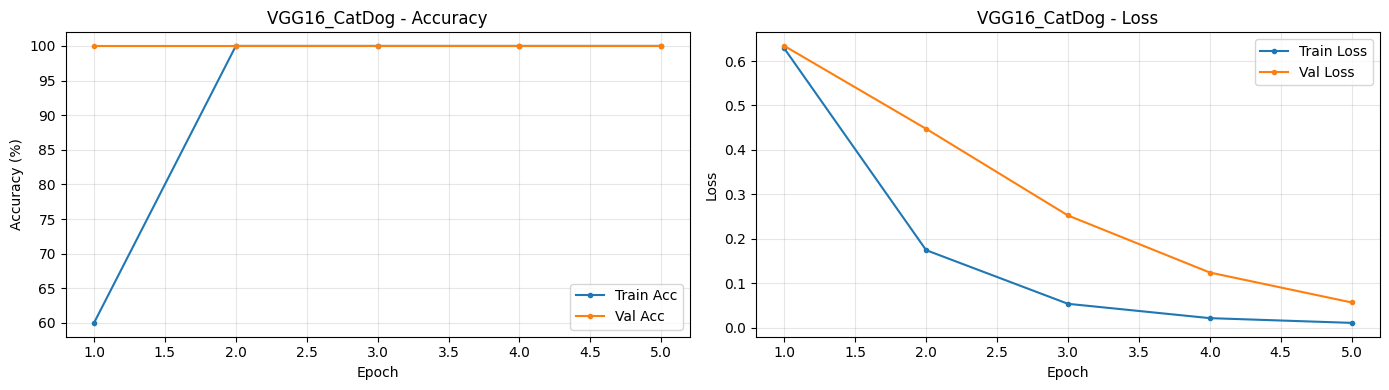

⏱️ train took 4.15s

✅ Baseline: 100.00%


In [ ]:
from reducnn.backends.torch_backend import PyTorchAdapter
from reducnn.pruner import ReduCNNPruner

adapter = PyTorchAdapter(config={'lr': 1e-4, 'input_shape': INPUT_SHAPE, 'num_classes': NUM_CLASSES})
model = adapter.get_model(MODEL_TYPE, pretrained=True)

print(f"🔥 Training {MODEL_TYPE} Baseline on {DATASET_NAME}...")
adapter.train(model, train_loader, epochs=5, name=f"{MODEL_TYPE}_{DATASET_NAME}", val_loader=test_loader)
b_acc = adapter.evaluate(model, test_loader)
print(f"\n✅ Baseline: {b_acc:.2f}%")

## 🔬 Advanced Core Concepts: Dynamic Tracing & Pruning Clusters

### 1. Dynamic Tracing
ReduCNN v0.6.4 utilizes **Dynamic Tracing** to handle complex architectures like ResNet and DenseNet. Instead of relying on static graph analysis, it performs a "dry run" with a sample input to map every dependency (additions, concatenations, and skip connections) in real-time.

### 2. Pruning Clusters
To maintain architectural integrity, ReduCNN groups dependent layers into **Pruning Clusters**. If one layer in a cluster is pruned, all others must be pruned identically to ensure tensor shapes align during operations like `torch.add` or `torch.cat`. This "all-or-nothing" approach prevents the common "dimension mismatch" errors in structural pruning.

In [ ]:
print(f"\n🔬 PRUNING: L1-Norm (Local 30%) on {MODEL_TYPE}")
surgeon = ReduCNNPruner(method='l1_norm', scope='local')
pruned_model, masks, duration = surgeon.prune(model, train_loader, ratio=0.3)

print("💊 Fine-tuning pruned model...")
adapter.train(pruned_model, train_loader, epochs=3, name=f"Heal_L1_{MODEL_TYPE}", val_loader=test_loader)
p_acc = adapter.evaluate(pruned_model, test_loader)
print(f"\n✅ Pruned Accuracy: {p_acc:.2f}%")


### C.1 PyTorch ResNet-18: Full Research Workflow (Cats vs Dogs)


In [ ]:
print(f'🧪 PYTORCH: {MODEL_TYPE} Full Suite ({DATASET_NAME})')
t_res_adapter = PyTorchAdapter(config={'lr': 1e-4, 'input_shape': INPUT_SHAPE, 'num_classes': NUM_CLASSES})
t_res_model = t_res_adapter.get_model(MODEL_TYPE, pretrained=True)

print(f'1. Establishing {MODEL_TYPE} Baseline...')
t_res_adapter.train(t_res_model, train_loader, epochs=2, name=f'{MODEL_TYPE}_Base', val_loader=test_loader)
res_base_acc = t_res_adapter.evaluate(t_res_model, test_loader)

print('\n2. Performing Structural Surgery (Local 20%)...')
res_surgeon = ReduCNNPruner(method='l1_norm', scope='local')
pruned_res, res_masks, _ = res_surgeon.prune(t_res_model, train_loader, ratio=0.2)

print('\n3. Healing Phase (Fine-tuning)...')
t_res_adapter.train(pruned_res, train_loader, epochs=3, name=f'{MODEL_TYPE}_Heal', val_loader=test_loader)
res_pruned_acc = t_res_adapter.evaluate(pruned_res, test_loader)

print(f'\n✅ {MODEL_TYPE} Results ({DATASET_NAME}):')
print(f'   Baseline Acc: {res_base_acc:.2f}%')
print(f'   Pruned Acc:   {res_pruned_acc:.2f}%')
viz.plot_layer_sensitivity(res_masks, f"{MODEL_TYPE} Pruning Sensitivity ({DATASET_NAME})")

In [ ]:
print(f'🔥 {MODEL_TYPE} + CHIP PRUNING ({DATASET_NAME})')
# 1. Setup Model
d_adapter = PyTorchAdapter(config={'lr': 1e-4, 'input_shape': INPUT_SHAPE, 'num_classes': NUM_CLASSES})
d_model = d_adapter.get_model(MODEL_TYPE)

# 2. Pruning with CHIP (Channel Independence-based Pruning)
d_surgeon = ReduCNNPruner(method='chip', scope='global')
print(f"🚀 Pruning {MODEL_TYPE} with CHIP...")
d_pruned, d_masks, _ = d_surgeon.prune(d_model, train_loader, ratio=0.4)

print("💊 Quick Heal (1 Epoch)...")
d_adapter.train(d_pruned, train_loader, epochs=1, name=f'{MODEL_TYPE}_CHIP', val_loader=test_loader)
d_acc = d_adapter.evaluate(d_pruned, test_loader)
print(f'\n✅ {MODEL_TYPE} (CHIP) Accuracy: {d_acc:.2f}%')

In [ ]:
from reducnn.visualization.animator import PruningAnimator

print('🎬 Generating X-Ray Pruning Animation...')
animator = PruningAnimator(t_res_adapter)
animator.show_dependency_sweep(t_res_model)
animator.show_shrinkage(t_res_model, res_masks)

In [ ]:
import time
import torch
from pathlib import Path


def benchmark_inference(model, loader, device, iterations=100):
    model.eval()
    # Extract a single sample for latency test
    it = iter(loader)
    x, _ = next(it)
    x = x[:1].to(device)

    # Warm-up
    with torch.no_grad():
        for _ in range(20):
            _ = model(x)

    # Timing
    start = time.time()
    with torch.no_grad():
        for _ in range(iterations):
            _ = model(x)
    end = time.time()

    latency = (end - start) / iterations * 1000  # ms
    return latency


def _infer_num_classes(model, adapter):
    if hasattr(model, 'fc') and hasattr(model.fc, 'out_features'):
        return int(model.fc.out_features)

    classifier = getattr(model, 'classifier', None)
    if classifier is not None:
        if hasattr(classifier, 'out_features'):
            return int(classifier.out_features)
        if isinstance(classifier, torch.nn.Sequential) and len(classifier) > 0 and hasattr(classifier[-1], 'out_features'):
            return int(classifier[-1].out_features)

    return int(getattr(adapter, 'config', {}).get('num_classes', 10))


def _stats(adapter, model, loader):
    flops, params = adapter.get_stats(model, loader)
    return float(flops), float(params)


def _fmt_stats(flops, params):
    return f"FLOPs={flops/1e6:.2f}M, Params={params/1e6:.2f}M"


def _save_reload_and_verify_models(adapter, baseline_model, pruned_model, loader, tag):
    ckpt_dir = Path('exports/notebook_checkpoints')
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    baseline_ckpt = ckpt_dir / f"{tag}_{MODEL_TYPE}_baseline_before_inference.pth"
    pruned_ckpt = ckpt_dir / f"{tag}_{MODEL_TYPE}_pruned_before_inference.pth"

    adapter.save_checkpoint(baseline_model, str(baseline_ckpt))
    adapter.save_checkpoint(pruned_model, str(pruned_ckpt))

    num_classes = _infer_num_classes(baseline_model, adapter)
    baseline_loaded = adapter.get_model(MODEL_TYPE, pretrained=False, num_classes=num_classes)
    pruned_loaded = adapter.get_model(MODEL_TYPE, pretrained=False, num_classes=num_classes)

    adapter.load_checkpoint(baseline_loaded, str(baseline_ckpt))
    adapter.load_checkpoint(pruned_loaded, str(pruned_ckpt))

    b_flops_orig, b_params_orig = _stats(adapter, baseline_model, loader)
    p_flops_orig, p_params_orig = _stats(adapter, pruned_model, loader)
    b_flops_load, b_params_load = _stats(adapter, baseline_loaded, loader)
    p_flops_load, p_params_load = _stats(adapter, pruned_loaded, loader)

    print('💾 Saved checkpoints:')
    print(f'   Baseline -> {baseline_ckpt.resolve()}')
    print(f'   Pruned   -> {pruned_ckpt.resolve()}')

    print('🔎 Verifying FLOPs/Params on saved-and-reloaded models:')
    print(f'   Baseline (in-memory): {_fmt_stats(b_flops_orig, b_params_orig)}')
    print(f'   Baseline (reloaded):  {_fmt_stats(b_flops_load, b_params_load)}')
    print(f'   Pruned   (in-memory): {_fmt_stats(p_flops_orig, p_params_orig)}')
    print(f'   Pruned   (reloaded):  {_fmt_stats(p_flops_load, p_params_load)}')

    return baseline_loaded, pruned_loaded


print('💾 Saving + reloading baseline/pruned models before inference...')
eval_loader = test_loader
infer_baseline_model, infer_pruned_model = _save_reload_and_verify_models(
    t_res_adapter,
    t_res_model,
    pruned_res,
    eval_loader,
    tag='cat_dog',
)

print('⏱️ Benchmarking Latency (Batch Size = 1) on reloaded models...')
t_orig = benchmark_inference(infer_baseline_model, eval_loader, t_res_adapter.device)
t_pruned = benchmark_inference(infer_pruned_model, eval_loader, t_res_adapter.device)

print(f'   Original {MODEL_TYPE} Latency: {t_orig:.3f} ms')
print(f'   Pruned {MODEL_TYPE} Latency:   {t_pruned:.3f} ms')
print(f'   🚀 Speedup: {(t_orig / t_pruned):.2f}x')


In [ ]:
print('🖼️ Generating Inference Gallery (using reloaded + verified checkpoints)...')
it = iter(eval_loader)
images, labels = next(it)
images_sub = images[:8]
labels_sub = labels[:8]

infer_baseline_model.eval()
infer_pruned_model.eval()
with torch.no_grad():
    p_orig = torch.argmax(infer_baseline_model(images_sub.to(t_res_adapter.device)), dim=1).cpu().numpy()
    p_pruned = torch.argmax(infer_pruned_model(images_sub.to(t_res_adapter.device)), dim=1).cpu().numpy()

class_names = ['cat', 'dog']
viz.plot_inference_gallery(
    images_sub.numpy(),
    labels_sub.numpy(),
    p_orig,
    p_pruned,
    class_names=class_names,
    title=f'{MODEL_TYPE}: Original vs. Pruned Predictions'
)


## Presentation Mode: Visual Diagnostics and Process Flow
This section is designed for demos and slides. It highlights:
1. Dependency graph and residual or concatenation clusters
2. Pruning candidate discovery (lowest-score channels)
3. Interactive X-ray graph walk (Discovery -> Importance -> Consistency -> Shrinkage)
4. Feature map visualization before and after pruning
5. Method agreement diagnostics (optional heavy step)


In [ ]:
# Presentation diagnostics utility (framework-agnostic, v0.6.6)
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import reducnn
import reducnn.visualization as viz
from reducnn.visualization.animator import PruningAnimator
from reducnn.analyzer.validator import MethodValidator

if tuple(map(int, reducnn.__version__.split('.'))) < (0, 6, 6):
    raise RuntimeError(f"Expected reducnn>=0.6.6, found {reducnn.__version__}")

def _resolve_from_globals(name_options):
    g = globals()
    for n in name_options:
        if n in g and g[n] is not None:
            return g[n], n
    return None, None

adapter, adapter_name = _resolve_from_globals(["adapter", "t_res_adapter", "k_adapter", "d_adapter", "dense_adapter"])
orig_model, model_name = _resolve_from_globals(["model", "t_res_model", "res_model", "dense_model", "d_model", "k_model"])
pruned_model, pruned_name = _resolve_from_globals(["pruned_model", "pruned_res", "h_model", "k_pruned", "pruned_dn", "d_pruned"])
masks, masks_name = _resolve_from_globals(["masks", "res_masks", "h_masks", "k_masks", "dn_masks", "d_masks"])
loader, loader_name = _resolve_from_globals(["test_loader", "train_loader", "loader", "val_loader", "t_test", "t_train", "k_test", "k_train"])

print(f"Resolved adapter: {adapter_name}")
print(f"Resolved original model: {model_name}")
print(f"Resolved pruned model: {pruned_name}")
print(f"Resolved masks: {masks_name}")
print(f"Resolved loader: {loader_name}")

if adapter is None or orig_model is None or loader is None:
    raise ValueError("Presentation diagnostics could not resolve adapter/model/loader. Run the main workflow first.")

if masks is None:
    masks = {}

score_method = "taylor"
try:
    score_map = adapter.get_score_map(orig_model, loader, score_method)
except Exception:
    score_method = "l1_norm"
    score_map = adapter.get_score_map(orig_model, loader, score_method)

print(f"Using score method for diagnostics: {score_method}")


In [ ]:
# 0) Optional: load a pre-trained checkpoint from repo/Drive path
# This enables prune-from-checkpoint workflows without baseline retraining.
LOAD_PRETRAINED_CHECKPOINT = False
PRETRAINED_CHECKPOINT_PATH = Path("my_models/pretrained_model.pth")  # Use .weights.h5 for Keras
if LOAD_PRETRAINED_CHECKPOINT:
    if PRETRAINED_CHECKPOINT_PATH.exists():
        adapter.load_checkpoint(orig_model, str(PRETRAINED_CHECKPOINT_PATH))
        print(f"Loaded pretrained checkpoint: {PRETRAINED_CHECKPOINT_PATH.resolve()}")
    else:
        print(f"Pretrained checkpoint not found: {PRETRAINED_CHECKPOINT_PATH}")

# 1) Trace graph and summarize dependency clusters
# Graph nodes = prunable conv nodes in the traced dependency graph.
# Clusters = residual add-linked layers that must share the same mask.
graph = adapter.trace_graph(orig_model)
clusters = graph.get("clusters", {})
print(f"Graph nodes: {len(graph.get('nodes', {}))}")
print(f"Pruning clusters: {len(clusters)}")
for cid, members in list(clusters.items())[:10]:
    print(f"  Cluster {cid}: {members[:8]}{' ...' if len(members) > 8 else ''}")

# 2) Build pruning candidate table (lowest-scoring channels per layer)
# candidate_count uses candidate_ratio (default 20% of each layer).
rows = []
candidate_ratio = 0.2
for layer_name, scores in score_map.items():
    s = np.asarray(scores, dtype=np.float64).reshape(-1)
    k = max(1, int(round(len(s) * candidate_ratio)))
    low_idx = np.argsort(s)[:k]
    rows.append({
        "layer": layer_name,
        "channels": len(s),
        "mean_score": float(np.mean(s)),
        "std_score": float(np.std(s)),
        "candidate_count": int(k),
        "candidate_indices": low_idx.tolist(),
    })

candidate_df = pd.DataFrame(rows).sort_values(["mean_score", "channels"], ascending=[True, False])
print("\nLowest-score candidate layers:")
display(candidate_df.head(20))

# 3) X-ray plotting pipeline
# show_dependency_sweep() prints Stage 1 cluster discovery text output.
# show_shrinkage() prints Stage 3 simulated channel shrink (orig -> kept).
# generate_xray_animation() plots a 4-frame graph: Discovery/Importance/Consistency/Shrink.
animator = PruningAnimator(adapter)
animator.show_dependency_sweep(orig_model)
if masks:
    animator.show_shrinkage(orig_model, masks)

fig = animator.generate_xray_animation(orig_model, score_map, masks)
animator.render(fig)

# 4) Feature map visualization before and after pruning
orig_viz = adapter.get_viz_data(orig_model, loader, num_layers=3)
viz.plot_feature_maps(orig_viz, title_prefix="Original Model")

if pruned_model is not None:
    try:
        pruned_viz = adapter.get_viz_data(pruned_model, loader, num_layers=3)
        viz.plot_feature_maps(pruned_viz, title_prefix="Pruned Model")
    except Exception as e:
        print(f"Skipped pruned feature maps: {e}")

# 5) Optional heavy method-agreement diagnostics
RUN_HEAVY_DIAGNOSTICS = False
if RUN_HEAVY_DIAGNOSTICS:
    methods = ["l1_norm", "apoz", "mean_abs_act"]
    MethodValidator().compare_methods(orig_model, loader, methods=methods, ratio=0.3)

# 6) Export artifacts + optional checkpoint persistence
import shutil

EXPORT_ARTIFACTS = True
SAVE_PRUNED_CHECKPOINT = True
SAVE_ORIGINAL_CHECKPOINT = False
COPY_TO_REPO_MODELS_DIR = True

export_dir = Path("exports")
repo_models_dir = Path("my_models")

def _default_ckpt_suffix(model_obj):
    t = str(type(model_obj)).lower()
    return ".weights.h5" if ("keras" in t or "tensorflow" in t) else ".pth"

def _save_ckpt(model_obj, stem_name):
    suffix = _default_ckpt_suffix(model_obj)
    out_path = export_dir / f"{stem_name}{suffix}"
    adapter.save_checkpoint(model_obj, str(out_path))
    print(f"Saved checkpoint: {out_path.resolve()}")
    if COPY_TO_REPO_MODELS_DIR:
        repo_models_dir.mkdir(parents=True, exist_ok=True)
        mirror_path = repo_models_dir / out_path.name
        shutil.copy2(out_path, mirror_path)
        print(f"Mirrored checkpoint: {mirror_path.resolve()}")

if EXPORT_ARTIFACTS:
    export_dir.mkdir(parents=True, exist_ok=True)
    candidate_path = export_dir / "pruning_candidates.csv"
    candidate_df.to_csv(candidate_path, index=False)

    if masks:
        masks_np = {k: np.asarray(v).astype(np.uint8) for k, v in masks.items()}
        np.savez_compressed(export_dir / "pruning_masks.npz", **masks_np)

    if SAVE_ORIGINAL_CHECKPOINT:
        _save_ckpt(orig_model, "original_model")
    if SAVE_PRUNED_CHECKPOINT and pruned_model is not None:
        _save_ckpt(pruned_model, "pruned_model")

    summary = {
        "version": reducnn.__version__,
        "score_method": score_method,
        "nodes": len(graph.get("nodes", {})),
        "clusters": len(clusters),
        "orig_stats": None,
        "pruned_stats": None,
    }
    try:
        summary["orig_stats"] = adapter.get_stats(orig_model, loader)
    except Exception:
        summary["orig_stats"] = adapter.get_stats(orig_model)
    if pruned_model is not None:
        try:
            summary["pruned_stats"] = adapter.get_stats(pruned_model, loader)
        except Exception:
            summary["pruned_stats"] = adapter.get_stats(pruned_model)

    with open(export_dir / "presentation_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, default=str)

    fig.write_html(str(export_dir / "presentation_pruning_xray.html"))
    print(f"Saved exports to: {export_dir.resolve()}")


In [ ]:
# --- Persist run tables to CSV artifacts (v0.88) ---
_saved_tables = persist_notebook_tables(locals(), prefix='run')
if _saved_tables:
    print('Saved CSV artifacts:')
    for _p in _saved_tables:
        print(' -', _p)
else:
    print('No matching tabular variables found for CSV export in this execution.')
